In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Guide illustré des tests d'hypothèses à l'aide de Python
Il s'agit d'un guide pratique sur les tests d'hypothèses, dans lequel nous utilisons à la fois les bibliothèques statistiques « codées à la main » et les bibliothèques statistiques communes, pour calculer différents tests statistiques.

Je pense que l'implémentation manuelle du test statistique sans package pourrait renforcer ma compréhension et c'est aussi quelque chose que j'ai remarqué que de nombreux articles de blog et de médias manquaient. J'espère que cet article aidera quelqu'un qui étudie ce domaine ou qui est actuellement coincé avec quelque chose.

Maintenant, avant d'aborder les tests d'hypothèses, nous devons parler de la distribution normale, qui est le plus gros rouage de tout l'ensemble, et de quelques fonctions pratiques que nous utiliserons pour calculer les composants importants des tests d'hypothèses.

## Distribution normale

In [2]:
#generate samples of normal distribution
from scipy.stats import norm
import scipy

### Générer des nombres aléatoires
Nous pourrions utiliser la fonction rvs de numpy pour générer des échantillons aléatoires pour différents types de distribution.
Pour les générer pour une distribution normale en utilisant les paramètres permettant de contrôler la moyenne et l'évolution standard :

In [3]:
r = norm.rvs(size=1000,loc=0, scale=1)

In [4]:
r[:10]

array([-0.47205964, -0.11145029,  1.47023501, -1.02220559, -0.30544927,
        1.20252574, -1.5583341 , -1.89900066, -0.55438698,  0.0895266 ])

### Visualisation de la distribution à l'aide d'un histogramme
L'histogramme montre la fréquence des valeurs.

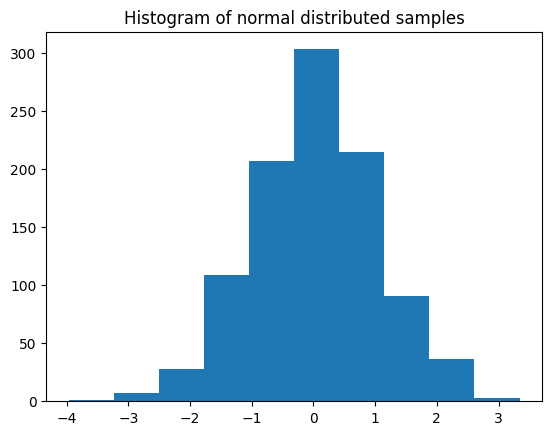

In [5]:
#visualize the normal distribution samples
plt.hist(r)
plt.title('Histogram of normal distributed samples')
plt.show()

### Fonction de densité de probabilité (PDF)
Si nous normalisons la proportion, nous obtiendrons un PDF dans lequel nous pourrions estimer la probabilité que la variable aléatoire ait une certaine valeur. PDF = version normalisée d'un histogramme.

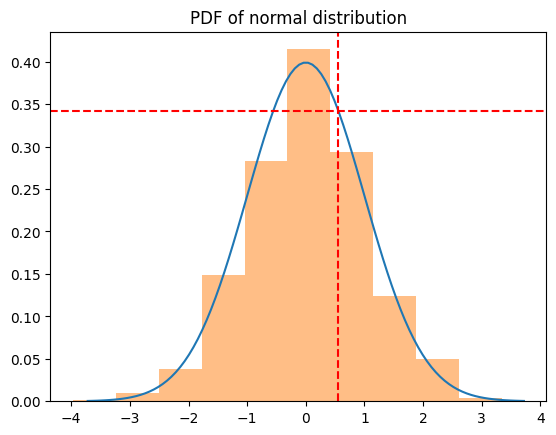

In [6]:
# linspace = Return evenly spaced numbers over a specified interval. params = start, stop, number of samples.
# used to generate uniform distribution samples
# in this case, we generate the ppf(std dev of the norm) for the plotting of X axis
x = np.linspace(norm.ppf(0.0001),norm.ppf(0.9999), 100)
plt.plot(x, norm.pdf(x))
plt.hist(r, density=True, histtype='stepfilled', alpha=0.5)
plt.axvline(x=0.55,color='r',linestyle='dashed')
plt.axhline(y=0.342,color='r',linestyle='dashed')
plt.title('PDF of normal distribution')
plt.show()

Cela répond à la question : sous une distribution normale, quelle est la probabilité que X soit égal à 1,4 ? Nous pourrions utiliser la fonction pdf de <b>numpy</b> pour découvrir :

In [7]:
# prob of 14.97% that random variable X has a value of 1.4
norm.pdf(1.4)

0.14972746563574488

Cependant, dire cette valeur à ce moment précis semble en fait étrange car il s'agit techniquement d'une variable continue. Et la bonne réponse serait 0.

### Fonction de distribution cumulative (CDF)

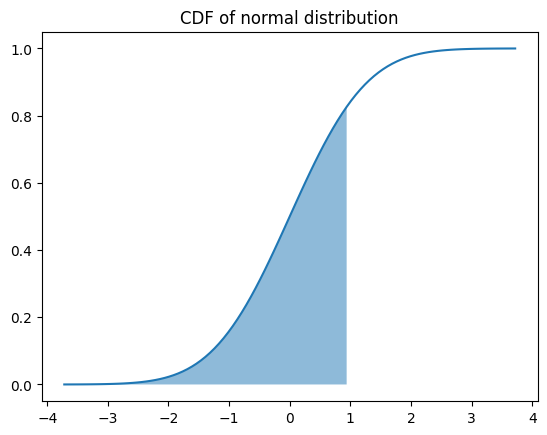

In [8]:
x = np.linspace(norm.ppf(0.0001),norm.ppf(0.9999), 100)
plt.plot(x, norm.cdf(x))
plt.fill_between(x[x<=1], 0, norm.cdf(x)[x<=1].flatten(),alpha=0.5)
plt.title('CDF of normal distribution')
plt.show()

En utilisant CDF, nous pourrions sonder des probabilités comme PDF mais sur un intervalle de valeurs : par exemple, quelle est la probabilité que X soit inférieur ou égal à 1,0 ? Ou P(x<=X). Dans le monde réel, cela pourrait signifier quelle est la probabilité de taille humaine entre un intervalle.

In [9]:
# 1.0 refers to the end of the interval, 84% that X <= 1.0
norm.cdf(1.0)

0.8413447460685429

### Fonction de point de pourcentage (PPF) - CDF inverse
Il répond à la question : étant donné la probabilité P(x<=X), quelle est la valeur de X

In [10]:
norm.ppf(0.8413447460685429)

1.0

## Quel test statistique pour tester des hypothèses ?
<img src='http://datageeko.com/imgs/stats_test_map_v1.jpg' width=700/>

## Test d'hypothèse sur 1 échantillon pour la différence de moyennes
Cas d'utilisation : lorsque nous souhaitons comparer la moyenne d'un échantillon à la moyenne d'une population ou à une valeur connue.

### Tests d'hypothèses à 2 queues

In [11]:
# Significant level(α)
alpha = 0.05/2
# Critical value for α
crit_val = norm.ppf(1-alpha)
crit_val

1.959963984540054

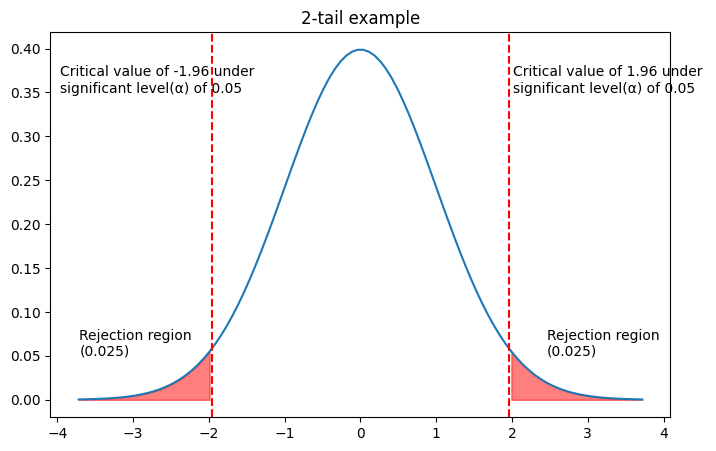

In [12]:
x = np.linspace(norm.ppf(0.0001),norm.ppf(0.9999), 100)
plt.figure(figsize=(8,5))
plt.plot(x, norm.pdf(x))
plt.fill_between(x[x>crit_val], 0, norm.pdf(x)[x>crit_val].flatten(),alpha=0.5, color='red')
plt.fill_between(x[x<-crit_val], 0, norm.pdf(x)[x<-crit_val].flatten(),alpha=0.5, color='red') # for left tail
plt.axvline(x=crit_val,color='r',linestyle='dashed')
plt.axvline(x=-crit_val,color='r',linestyle='dashed') # for left tail
plt.text(crit_val+0.05, 0.35, 'Critical value of {} under \nsignificant level(α) of {}'.format(round(crit_val,2), str(alpha*2)), fontsize=10)
plt.text(-crit_val-2, 0.35, 'Critical value of {} under \nsignificant level(α) of {}'.format(round(-crit_val,2), str(alpha*2)), fontsize=10)# for left tail
plt.text(crit_val+0.5, 0.05, 'Rejection region\n('+str(alpha)+')', fontsize=10)
plt.text(-crit_val-1.75, 0.05, 'Rejection region\n('+str(alpha)+')', fontsize=10) #for left tail
plt.title('2-tail example')
plt.show()

La région de rejet est divisée en 2 queues, ce qui donne un total de 0,05. <b>Notez que la valeur critique sous alpha de 0,05 est 1,96.</b>

La ligne rouge pointillée représente le niveau significatif de 0,05. En utilisant le CDF, nous pourrions calculer P(x>X) qui est mis en évidence dans la zone ombrée illustrée ci-dessus et puisque les intégrales CDF x<=X, nous faisons un 1-P(x<=X). Cette zone ombrée signifie également que si les statistiques de test se situent dans cette zone ombrée, nous rejetterions l'hypothèse nulle car la valeur p des statistiques de test est inférieure à 0,05.

#### Exemple 1 à 2 queues - Différence de moyennes, valeur de p faible
Disons que nous avons l'hypothèse que les basketteurs de l'équipe ABC sont différents (supérieurs ou inférieurs) au niveau national (population). Nous tirons donc un échantillon de 100 tailles de joueurs de l'équipe ABC et déterminons si cette distribution est différente de la distribution de la population, ou en d'autres termes, comparons la moyenne de l'échantillon à une valeur connue qui est la moyenne de la population dans ce cas.

Hypothèse nulle ($H_{0}$) : Il existe une différence <b>NO</b> entre la taille des joueurs de basket-ball de l'équipe ABC et celle du pays.

Hypothèse alternative ($H_{1}$) : Il existe une différence entre la taille des joueurs de basket-ball de l'équipe ABC et celle du pays.

Nous générons des échantillons aléatoires pour illustrer cet exemple.

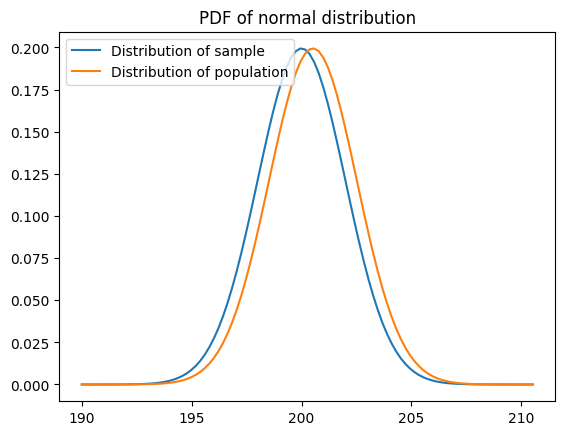

In [13]:
random.seed(888), np.random.seed(888) #very important: set random seed.
s1_mean,s1_stddev = 200, 2 # sample has mean of 200, std dev of 2
s1_samples = norm.rvs(size=100,loc=s1_mean, scale=s1_stddev)
pop_mu, pop_sigma = 200.52, 2 # population has mean of 210, std dev of 2
x = np.linspace(s1_mean-10, pop_mu+10, 100)
plt.plot(x, norm.pdf(x,s1_mean,s1_stddev), label='Distribution of sample')
plt.plot(x, norm.pdf(x, pop_mu, pop_sigma), label='Distribution of population')
#plt.fill_between(x[x>hl_z], 0, norm.pdf(x)[x>hl_z].flatten(),alpha=0.5)
#plt.axvline(x=sign_level_score,color='r',linestyle='dashed')
#plt.fill_between(x[x<=1], 0, norm.cdf(x)[x<=1].flatten(),alpha=0.5)
plt.title('PDF of normal distribution')
plt.legend(loc="upper left")
plt.show()

#### Calculez le Z-Score pour la différence de moyennes
La formule formelle et la plus simple du Z-Score qui a été présentée pour la première fois à de nombreux étudiants est :
$$z = \frac{\bar{x}-\mu}{\sigma}$$
C'est le cas où l'on connaît le standard de population dev(sigma).

In [14]:
(pop_mu-s1_samples.mean())/pop_sigma

0.20428400539231006

Cependant, en pratique, nous n'avons pas la population std dev. Par conséquent, nous pourrions soit l'approcher en utilisant un exemple de développement std :
$$z = \frac{\bar{x}-\mu}{ \frac{s}{ \sqrt{n} } }$$
Remarque importante : puisque nous nous rapprochons de <b> de </b> de l'exemple de développement standard, nous devons utiliser le développement standard <a href='https://en.wikipedia.org/wiki/Standard_deviation#Corrected_sample_standard_deviation'><b> corrigé </b></a> :
<img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/df695c81f11c7d0d27209a42c72c20d2ad4e1fd2' width=200/>
Le « N-1 » correspond au nombre de degrés de liberté dans le vecteur des écarts par rapport à la moyenne, et permet d'obtenir la variance d'échantillon non biaisée.

In [15]:
#hand coded, NOTE: np.std() accepts the ddof to handle the correction
z_score = (s1_samples.mean()-pop_mu) / (np.std(s1_samples, ddof=1)/np.sqrt(len(s1_samples)))
z_score

-2.0146215084517616

Nous utilisons la fonction CDF pour connaître l'aire sous la courbe pour X<= z_score <b> sous une distribution normale de moyenne 0 et de développement standard 1</b>, et multiple par 2 puisqu'il s'agit d'un test à 2 queues ; le CDF renvoie 1 côté de la queue et nous vérifions la région de rejet sur la queue gauche ou droite.

In [16]:
#find out p-value: manual method
#NOTE: we take the absolute of z-score because we want to retrieve the area(to the left) under a right-tail distribution setting
(1-norm.cdf(abs(z_score)))*2

0.04394432208981236

Alternativement, nous pourrions utiliser la bibliothèque <a href="https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ztest.html"><b>statsmodel</b></a> pour ce faire. Remarque importante : bien qu'il soit facile de simplement brancher les chiffres, il vaut la peine de savoir ce qui se cache sous le capot pour éviter de tester les mauvaises choses.

In [17]:
from statsmodels.stats.weightstats import ztest
#find out p-value: statsmodel method, 2 tail test
test_stat, p_value = ztest(x1=s1_samples, value=pop_mu, alternative='two-sided')
test_stat, p_value

(-2.0146215084517616, 0.043944322089812436)

Elle renvoie les mêmes résultats que la méthode de calcul manuel. Ouf ! Alors, que signifie cette valeur p ? Être proche de 0 (<0,05) signifie qu'il y a une différence entre la distribution, ou qu'il y a une réelle différence dans la moyenne.

In [18]:
first_z_score, first_p_val = z_score, p_value

#### Calculer le score T pour la différence de moyennes
Si le nombre d'échantillons est petit (<30) ou si l'évolution standard de la population est inconnue, il est recommandé d'utiliser un test t à la place.
$$z = \frac{\bar{x}-\mu}{ \frac{s}{ \sqrt{n} } }$$
 où $df = n-1$

In [19]:
#hand coded, NOTE: np.std() accepts the ddof to handle the correction
t_score = (s1_samples.mean()-pop_mu) / (np.std(s1_samples, ddof=1)/np.sqrt(len(s1_samples)))
df = len(s1_samples)-1
t_score, df

(-2.0146215084517616, 99)

In [20]:
#find out p-value: manual method, NOTE: we use the absolute of t-score
from scipy.stats import t
(1-t.cdf(abs(t_score),df))*2

0.04665636936473416

Utilisez le package <a href='https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html'>scipy</a> pour effectuer le test t à 1 échantillon. Notez qu'il renvoie les résultats pour le test bilatéral uniquement.

In [21]:
#find out p-value: scipy method, 2 tail test,
test_stat, p_value = scipy.stats.ttest_1samp(s1_samples, popmean=pop_mu)
test_stat, p_value

(-2.014621508451761, 0.04665636936473418)

La valeur p calculée à partir de la version codée à la main et de scipy est presque la même. La valeur p est très proche de la version du test z, probablement en raison du grand nombre d'échantillons.

#### Exemple 2-tail 2 - Différence de moyennes, valeur p élevée
Répétons ce qui précède avec une distribution plus étroite pour simuler un cas où il n'y a pas de réelle différence, comme le montre le petit chevauchement ci-dessous :

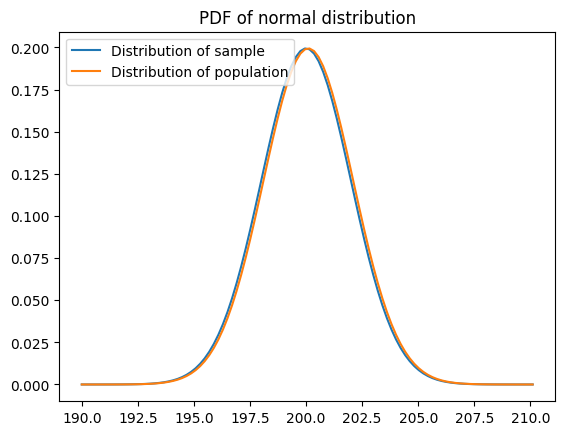

In [22]:
random.seed(888), np.random.seed(888) #very important: set random seed.
s1_mean,s1_stddev = 200, 2 # sample has mean of 200, std dev of 2
s1_samples = norm.rvs(size=100,loc=s1_mean, scale=s1_stddev)
pop_mu, pop_sigma = 200.1, 2 # population has mean of 210, std dev of 2
x = np.linspace(s1_mean-10, pop_mu+10, 100)
plt.plot(x, norm.pdf(x,s1_mean,s1_stddev), label='Distribution of sample')
plt.plot(x, norm.pdf(x, pop_mu, pop_sigma), label='Distribution of population')
#plt.fill_between(x[x>hl_z], 0, norm.pdf(x)[x>hl_z].flatten(),alpha=0.5)
#plt.axvline(x=sign_level_score,color='r',linestyle='dashed')
#plt.fill_between(x[x<=1], 0, norm.cdf(x)[x<=1].flatten(),alpha=0.5)
plt.title('PDF of normal distribution')
plt.legend(loc="upper left")
plt.show()

In [23]:
#hand coded, np.std() accepts the ddof to handle the corretion
z_score = (s1_samples.mean()-pop_mu) / (np.std(s1_samples, ddof=1)/np.sqrt(len(s1_samples)))
#find out p-value: manual method
z_score, (1-norm.cdf(abs(z_score)))*2

(0.0563703734746526, 0.9550467579570607)

In [24]:
#find out p-value: statsmodel method, 2 tail test
test_stat, p_value = ztest(x1=s1_samples, value=pop_mu, alternative='two-sided')
test_stat, p_value

(0.0563703734746526, 0.9550467579570608)

Dans ce cas, la valeur p est beaucoup plus élevée (> 0,05) et nous ne parvenons pas à rejeter l'hypothèse nulle. Tout comme ce que les tracés tentent de nous dire, il n'y a aucune différence entre les 2 distributions.

In [25]:
#hand coded, NOTE: np.std() accepts the ddof to handle the correction
t_score = (s1_samples.mean()-pop_mu) / (np.std(s1_samples, ddof=1)/np.sqrt(len(s1_samples)))
df = len(s1_samples)-1
#find out p-value: manual method
t_score, df, (1-t.cdf(abs(t_score), df))*2

(0.0563703734746526, 99, 0.9551603706476555)

In [26]:
#find out p-value: scipy method, 2 tail test,
test_stat, p_value = scipy.stats.ttest_1samp(s1_samples, popmean=pop_mu)
test_stat, p_value

(0.056370373474652596, 0.9551603706476554)

In [27]:
second_z_score, second_p_val = z_score, p_value

### Illustration de la région de rejet à 2 queues
Une façon efficace et intuitive d'y réfléchir est de rappeler le tracé précédent (illustré à nouveau ici) d'une distribution normale où le centre est la différence de 0 entre les 2 groupes, et nous voulons savoir si le score z se trouve dans la région de rejet.

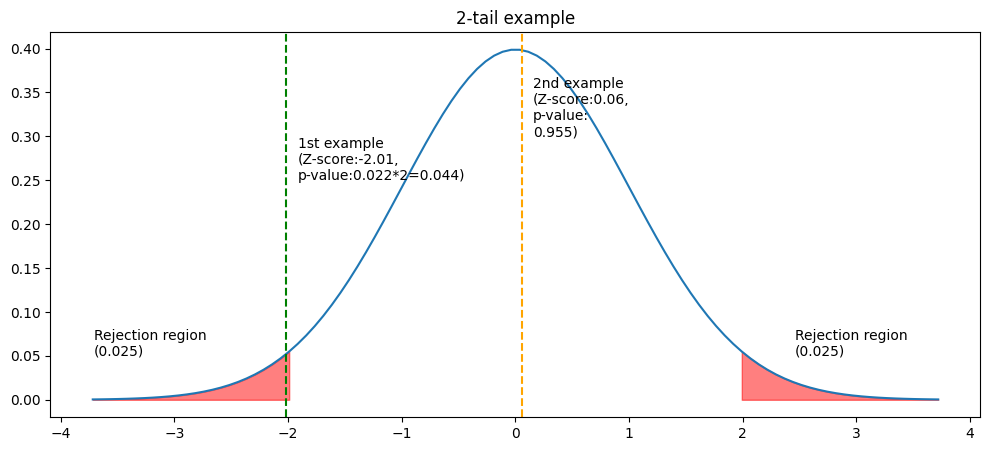

In [28]:
# Significant level(α) # Critical value for α
alpha, crit_val = 0.05, norm.ppf(1-alpha)
x = np.linspace(norm.ppf(0.0001),norm.ppf(0.9999), 100)
plt.figure(figsize=(12,5))
plt.plot(x, norm.pdf(x))
plt.fill_between(x[x>crit_val], 0, norm.pdf(x)[x>crit_val].flatten(),alpha=0.5, color='red')
plt.fill_between(x[x<-crit_val], 0, norm.pdf(x)[x<-crit_val].flatten(),alpha=0.5, color='red') # for left tail
plt.axvline(x=first_z_score,color='green',linestyle='dashed') # for left tail
plt.axvline(x=second_z_score,color='orange',linestyle='dashed') # for left tail
plt.text(crit_val+0.5, 0.05, 'Rejection region\n('+str(alpha/2)+')', fontsize=10)
plt.text(-crit_val-1.75, 0.05, 'Rejection region\n('+str(alpha/2)+')', fontsize=10) #for left tail
plt.text(first_z_score+0.1, 0.25, '1st example\n(Z-score:{},\np-value:{}*2={})'.format(round(first_z_score,2), round(first_p_val/2,3), round(first_p_val,3)), fontsize=10) #for left tail
plt.text(second_z_score+0.1, 0.30, '2nd example\n(Z-score:{},\np-value:\n{})'.format(round(second_z_score,2), round(second_p_val,3)), fontsize=10) #for left tail
plt.title('2-tail example')
plt.show()

Nous avons pu voir que le score z (vert) est dans la région de rejet et cela conduit au rejet de l'hypothèse nulle.
D'un autre côté, le score z (orange) n'est pas dans la région de rejet et cela conduit à l'échec du rejet de l'hypothèse nulle.

### Test d'hypothèse à 1 queue (queue droite)

In [29]:
# Significant level(α)
alpha = 0.05
# Critical value for α
crit_val = norm.ppf(1-alpha)
crit_val

1.6448536269514722

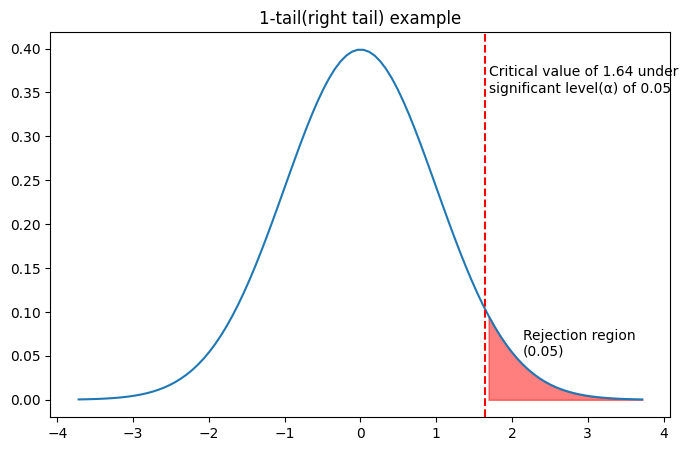

In [30]:
x = np.linspace(norm.ppf(0.0001),norm.ppf(0.9999), 100)
plt.figure(figsize=(8,5))
plt.plot(x, norm.pdf(x))
plt.fill_between(x[x>crit_val], 0, norm.pdf(x)[x>crit_val].flatten(),alpha=0.5, color='red')
plt.axvline(x=crit_val,color='r',linestyle='dashed')
plt.text(crit_val+0.05, 0.35, 'Critical value of {} under \nsignificant level(α) of {}'.format(round(crit_val,2), str(alpha)), fontsize=10)
plt.text(crit_val+0.5, 0.05, 'Rejection region\n('+str(alpha)+')', fontsize=10)
plt.title('1-tail(right tail) example')
plt.show()

Par rapport à l'exemple précédent à 2 queues, dans cette version à 1 queue, la région de rejet se trouve uniquement sur une </b>single tail</b> qui est à 0,05. <b>Notez que la valeur critique sous alpha de 0,05 est de 1,645 au lieu de 1,96</b>

#### Exemple 1-tail 1 - Différence de moyennes, valeur p faible
Disons que nous avons l'hypothèse que les joueurs de baseball de l'équipe ABC sont <b>plus élevés</b> que le niveau national (population). Nous tirons donc un échantillon de 100 tailles de joueurs de l'équipe ABC et déterminons si cette distribution est différente de la distribution de la population, ou en d'autres termes, comparons la moyenne de l'échantillon à une valeur connue qui est la moyenne de la population dans ce cas.

Hypothèse nulle ($H_{0}$) : Il existe une différence <b>NO</b> entre la taille des joueurs de basket-ball de l'équipe ABC et celle du pays.

Hypothèse alternative ($H_{1}$) : La taille des joueurs de basket-ball de l'équipe ABC est plus élevée que celle du pays.

Nous générons des échantillons aléatoires pour illustrer cet exemple.

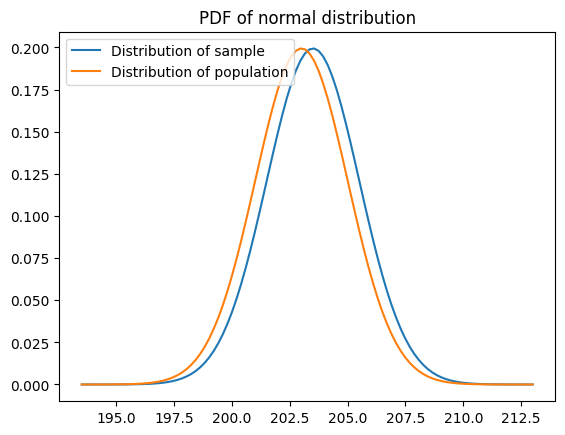

In [31]:
random.seed(888), np.random.seed(888) #very important: set random seed.
s1_mean,s1_stddev = 203.5, 2 # sample has mean of 200, std dev of 2
s1_samples = norm.rvs(size=100,loc=s1_mean, scale=s1_stddev)
pop_mu, pop_sigma = 203, 2 # population has mean of 210, std dev of 2
x = np.linspace(s1_mean-10, pop_mu+10, 100)
plt.plot(x, norm.pdf(x,s1_mean,s1_stddev), label='Distribution of sample')
plt.plot(x, norm.pdf(x, pop_mu, pop_sigma), label='Distribution of population')
#plt.fill_between(x[x>hl_z], 0, norm.pdf(x)[x>hl_z].flatten(),alpha=0.5)
#plt.axvline(x=sign_level_score,color='r',linestyle='dashed')
#plt.fill_between(x[x<=1], 0, norm.cdf(x)[x<=1].flatten(),alpha=0.5)
plt.title('PDF of normal distribution')
plt.legend(loc="upper left")
plt.show()

#### Calculez le Z-Score pour la différence de moyennes
Nous utilisons la même méthode de calcul que celle expliquée précédemment.

In [32]:
#hand coded, NOTE: np.std() accepts the ddof to handle the correction
z_score = (s1_samples.mean()-pop_mu) / (np.std(s1_samples, ddof=1)/np.sqrt(len(s1_samples)))
#find out p-value: manual method
z_score, 1-norm.cdf(z_score)

(3.014930204797961, 0.001285191987069445)

Nous effectuons un 1-CDF car le CDF renvoie la zone sur la zone gauche de la courbe à partir de la valeur critique, et nous voulons plutôt la zone sur la droite (zone rouge surlignée ci-dessus)

In [33]:
#find out p-value: statsmodel method, 1-tail: NOTE: use "larger" for alternative param!
test_stat, p_value = ztest(x1=s1_samples, value=pop_mu, alternative='larger')
test_stat, p_value

(3.014930204797961, 0.0012851919870694563)

In [34]:
first_z_score, first_p_val = z_score, p_value

Elle renvoie les mêmes résultats que la méthode de calcul manuel. Ouf ! Alors, que signifie cette valeur p ? Être proche de 0 (<0,05) signifie qu'il y a une différence entre la distribution, ou qu'il y a une réelle différence dans la moyenne.

#### Exemple 1-tail 2 - Différence de moyennes, valeur p élevée
Répétons ce qui précède avec une distribution plus étroite pour simuler un cas où il n'y a pas de réelle différence, comme le montre le petit chevauchement ci-dessous :

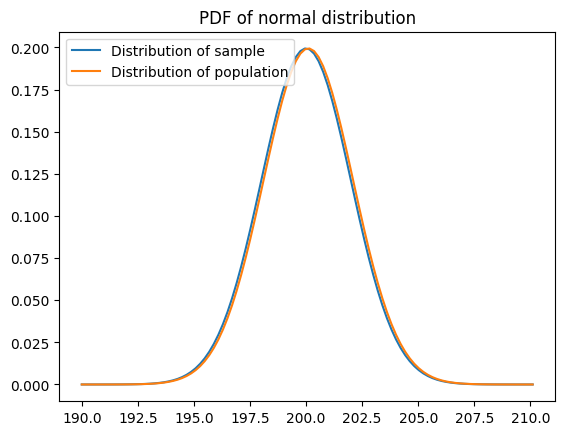

In [35]:
random.seed(888), np.random.seed(888) #very important: set random seed.
s1_mean,s1_stddev = 200, 2 # sample has mean of 200, std dev of 2
s1_samples = norm.rvs(size=100,loc=s1_mean, scale=s1_stddev)
pop_mu, pop_sigma = 200.1, 2 # population has mean of 210, std dev of 2
x = np.linspace(s1_mean-10, pop_mu+10, 100)
plt.plot(x, norm.pdf(x,s1_mean,s1_stddev), label='Distribution of sample')
plt.plot(x, norm.pdf(x, pop_mu, pop_sigma), label='Distribution of population')
#plt.fill_between(x[x>hl_z], 0, norm.pdf(x)[x>hl_z].flatten(),alpha=0.5)
#plt.axvline(x=sign_level_score,color='r',linestyle='dashed')
#plt.fill_between(x[x<=1], 0, norm.cdf(x)[x<=1].flatten(),alpha=0.5)
plt.title('PDF of normal distribution')
plt.legend(loc="upper left")
plt.show()

In [36]:
#hand coded, NOTE: np.std() accepts the ddof to handle the correction
z_score = (s1_samples.mean()-pop_mu) / (np.std(s1_samples, ddof=1)/np.sqrt(len(s1_samples)))
#find out p-value: manual method
z_score, 1-norm.cdf(abs(z_score))

(0.0563703734746526, 0.47752337897853037)

Nous effectuons un 1-CDF car le CDF renvoie la zone sur la zone gauche de la courbe à partir de la valeur critique, et nous voulons plutôt la zone sur la droite (zone rouge surlignée ci-dessus)

In [37]:
#find out p-value: statsmodel method, 1-tail: NOTE: use "larger" for alternative param!
test_stat, p_value = ztest(x1=s1_samples, value=pop_mu, alternative='larger')
test_stat, p_value

(0.0563703734746526, 0.4775233789785304)

Dans ce cas, la valeur p est beaucoup plus élevée (> 0,05) et nous ne parvenons pas à rejeter l'hypothèse nulle. Tout comme ce que les tracés tentent de nous dire, il n'y a aucune différence entre les 2 distributions.

In [38]:
second_z_score, second_p_val = z_score, p_value

### Illustration de la région de rejet à 1 queue
Une façon efficace et intuitive d'y réfléchir est de rappeler le tracé précédent (illustré à nouveau ici) d'une distribution normale où le centre est la différence de 0 entre les 2 groupes, et nous voulons savoir si le score z se trouve dans la région de rejet.

In [39]:
crit_val

1.6448536269514722

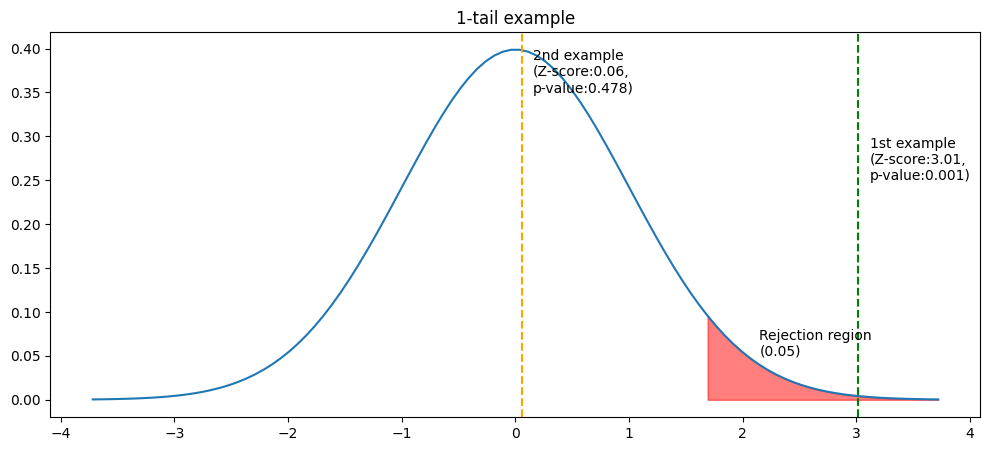

In [40]:
# Significant level(α)
alpha = 0.05
# Critical value for α
crit_val = norm.ppf(1-alpha)
x = np.linspace(norm.ppf(0.0001),norm.ppf(0.9999), 100)
plt.figure(figsize=(12,5))
plt.plot(x, norm.pdf(x))
plt.fill_between(x[x>crit_val], 0, norm.pdf(x)[x>crit_val].flatten(),alpha=0.5, color='red')
plt.axvline(x=first_z_score,color='green',linestyle='dashed') # for left tail
plt.axvline(x=second_z_score,color='orange',linestyle='dashed') # for left tail
plt.text(crit_val+0.5, 0.05, 'Rejection region\n('+str(alpha)+')', fontsize=10)
plt.text(first_z_score+0.1, 0.25, '1st example\n(Z-score:{},\np-value:{})'.format(round(first_z_score,2), round(first_p_val,3)), fontsize=10) #for left tail
plt.text(second_z_score+0.1, 0.35, '2nd example\n(Z-score:{},\np-value:{})'.format(round(second_z_score,2), round(second_p_val,3)), fontsize=10) #for left tail
#plt.text(second_z_score+0.1, 0.35, 'Z-score for\n2nd example', fontsize=10) #for left tail
plt.title('1-tail example')
plt.show()

Nous avons pu voir que le score z (vert) est dans la région de rejet et cela conduit au rejet de l'hypothèse nulle.
D'un autre côté, le score z (orange) n'est pas dans la région de rejet et cela conduit à l'échec du rejet de l'hypothèse nulle.

## Test d'hypothèse sur 1 échantillon pour déterminer la différence de proportions

In [41]:
from scipy.stats import binom

Nous créons une distribution binomiale <b></b> pour représenter les proportions d'échantillon et de population à l'aide de 100 tirages au sort (une série d'essais de Bernoulli), avec une probabilité de 0,55 et 0,5 de tête de chaque essai pour l'échantillon et la population respectivement.

Remarque : chaque essai de Bernoulli n'a que deux résultats possibles (succès ou échec) et le paramètre p décrit la probabilité de succès.

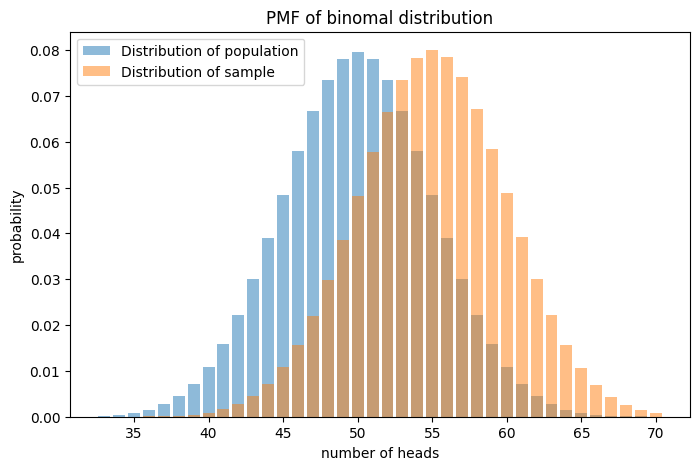

In [42]:
plt.figure(figsize=(8,5))
pop_n, pop_p = 100, 0.5
s1_samples_n, s1_samples_p = 100, 0.55
x = np.arange(binom.ppf(0.01, pop_n, pop_p)-5,binom.ppf(0.99, s1_samples_n, s1_samples_p)+5)
plt.bar(x, binom.pmf(x, n=pop_n, p=pop_p), alpha=0.5, label='Distribution of population')
plt.bar(x, binom.pmf(x, n=s1_samples_n, p=s1_samples_p), alpha=0.5, label='Distribution of sample')
plt.title('PMF of binomal distribution')
plt.legend(loc="upper left"), plt.xlabel('number of heads'), plt.ylabel('probability')
plt.show()

D’après le PMF, nous avons pu constater que la répartition de la population culmine à 55, ce qui signifie que sur 100 tirages au sort, nous devrions obtenir 55 têtes la plupart du temps. Nous pourrions également voir une certaine probabilité d'obtenir d'autres nombres en fonction de la variance.

### Tests d'hypothèses à 2 queues
Hypothèse nulle ($H_{0}$) : la pièce est juste ; Il existe une différence <b>NO</b> entre les échantillons de pièces et toutes les autres pièces.

Hypothèse alternative ($H_{1}$) : La pièce est injuste ; Il y a une différence entre les échantillons de pièces et toutes les autres pièces.

#### Calculer le test z pour la différence de proportions
$$z = \frac{\hat{p}-p_0}{  \sqrt{\frac{p_0(1-p_0)}{n}} }$$
 où le dénominateur est en fait le développement standard d'une distribution binomiale

In [43]:
# manual method
z_score = (s1_samples_p - pop_p)/(np.sqrt( (pop_p*(1-pop_p))/s1_samples_n))
z_score, (1-norm.cdf(abs(z_score)))*2

(1.0000000000000009, 0.3173105078629137)

Encore une fois, nous pourrions utiliser la fonction <a href='https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html'>z-test</a> pour les proportions dans la bibliothèque statsmodel pour exécuter le test en 1 ligne :

In [44]:
#NOTE these parameters:
#count: number of successes, nobs: number of trials, value: hypothesized population proportion
#alternative: The alt hypo, prop_var: use sample proportion to estimate(must set it to population proportion instead!)
from statsmodels.stats.proportion import proportions_ztest
count = int(s1_samples_n* s1_samples_p)
proportions_ztest(count, nobs=s1_samples_n, value=pop_p, alternative='two-sided', prop_var=0.50)

(1.0000000000000009, 0.3173105078629137)

Au début, j'avais des résultats différents jusqu'à ce que je tombe sur <a href='https://stats.stackexchange.com/questions/447462/why-does-the-proportions-ztest-function-in-statsmodels-produce-different-values'>, ce post utile </a> où quelqu'un avait des problèmes similaires. Il s'avère que statsmodel a utilisé par défaut la proportion d'échantillon pour le calcul de l'erreur type.

Quoi qu’il en soit, les deux méthodes nous donnent la même valeur p.

## <font color='red'>Independent</font> Test d'hypothèse à 2 échantillons pour la différence dans les moyennes des échantillons
Lorsque nous voulons comparer la moyenne d’un échantillon à celle d’une autre moyenne d’échantillon. L'utilisation de ce test dépend de quelques critères : si vous connaissez l'écart type de la population derrière l'échantillon et s'ils sont égaux. Reportez-vous à la taxonomie pour une ventilation visuelle.

<b>Cas d'utilisation : </b>
Disons que nous avons prélevé 2 petits échantillons :

1) Tailles de 50 basketteurs nordistes (sur 5000)

2) Hauteurs de 50 basketteurs sudistes (sur 5000)

et nous voulons savoir s'il y a une différence entre la taille de la véritable population derrière ces échantillons (par exemple, les 5 000 joueurs du nord sont soit plus grands, soit plus petits que les 5 000 joueurs du sud). N'oubliez pas que l'échantillon est une représentation ou une estimation de la population et que nous souhaitons en fin de compte déduire la conclusion dans le contexte de l'ensemble de la population.

### Exemple 1 à 2 queues - Différence dans les moyennes de l'échantillon

Hypothèse nulle ($H_{0}$) : il existe une différence <b>NO</b> entre la taille des joueurs de basket-ball du nord et du sud.

Hypothèse alternative ($H_{1}$) : Il existe une différence entre la taille des basketteurs du nord et du sud.

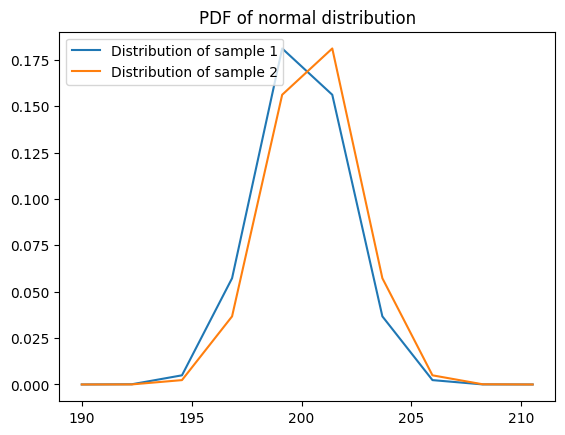

In [45]:
random.seed(888), np.random.seed(888) #very important: set random seed.
s1_mean,s1_stddev = 200, 2 # sample has mean of 200, std dev of 2
s1_samples = norm.rvs(size=50,loc=s1_mean, scale=s1_stddev)
s2_mean, s2_stddev = 200.52, 2 # population has mean of 210, std dev of 2
s2_samples = norm.rvs(size=50,loc=s2_mean, scale=s2_stddev)
x = np.linspace(s1_mean-10, s2_mean+10, 10)
plt.plot(x, norm.pdf(x,s1_mean,s1_stddev), label='Distribution of sample 1')
plt.plot(x, norm.pdf(x, s2_mean, s2_stddev), label='Distribution of sample 2')
plt.title('PDF of normal distribution')
plt.legend(loc="upper left")
plt.show()

### Lorsque vous ne connaissez pas l'écart type de la population (<font color='red'>$\sigma_1,\sigma_2$ inconnue</font>) et <font color='red'>$\sigma_1\neq\sigma_2$</font>
Utiliser les mêmes échantillons qu'avant

#### Calculer le test t non poolé sur 2 échantillons pour la différence de moyenne
Nous utilisons le test t de variance <font color='red'><b>non-pooled</b></font> ou communément appelé test t de Welch.

$$t = \frac{\bar{x_1}-\bar{x_2}}{\sqrt{  \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}   } }$$
où le degré de libertés (df) est :
$$
df \approx \frac{\left(\frac{s_{1}^{2}}{N_{1}}+\frac{s_{2}^{2}}{N_{2}}\right)^{2}}{\frac{s_{1}^{4}}{N_{1}^{2} df_{1}}+\frac{s_{2}^{4}}{N_{2}^{2} df_{2}}}
$$
et $df_1$ et $df_2$ sont respectivement les df pour les 1er et 2ème échantillons.

Nous ignorons la version manuelle pour celle-ci car elle comporte trop de parties. Nous pourrions utiliser la fonction statsmodels, <a href='https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ttest_ind.html'>ttest_ind</a> pour calculer le test t.

In [46]:
from statsmodels.stats.weightstats import ttest_ind
# do a non-pool t-test by passing 'unequal' into the usevar to indicate the unequal var
t_stat, p_value, df = ttest_ind(s2_samples,s1_samples,alternative='two-sided',usevar='unequal')
t_stat, p_value, df

(2.5207890108015234, 0.013439625952883746, 91.55812475043417)

Il renvoie les statistiques t, la valeur p et le degré de liberté utilisé dans le calcul.

### Lorsque vous ne connaissez pas l'écart type de la population (<font color='red'>$\sigma_1,\sigma_2$ inconnue</font>) et <font color='red'>$\sigma_1=\sigma_2$</font>

#### Calculer le test t poolé de 2 échantillons pour la différence de moyenne
Nous utilisons le test t de variance <font color='red'><b>pooled</b></font> :

$$t = \frac{\bar{x_1}-\bar{x_2}}{\sqrt{ (S_p^2) \frac{1}{n_1} + \frac{1}{n_2}   } }$$
où la variance groupée est :
$$
s_{p}^{2}=\frac{\left(n_{1}-1\right) s_{1}^{2}+\left(n_{2}-1\right) s_{2}^{2}}{n_{1}+n_{2}-2}
$$

Nous ignorons la version manuelle pour celle-ci car elle comporte trop de parties. Nous pourrions utiliser les mêmes modèles de statistiques, la fonction <a href='https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ttest_ind.html'>ttest_ind</a> pour calculer le test t.

In [47]:
from statsmodels.stats.weightstats import ttest_ind
# do a non-pool t-test by passing 'pooled' into the usevar to indicate the unequal var
t_stat, p_value, df = ttest_ind(s2_samples,s1_samples,alternative='two-sided',usevar='pooled')
t_stat, p_value, df

(2.5207890108015234, 0.013323109728081253, 98.0)

Il renvoie les statistiques t, la valeur p et le degré de liberté utilisé dans le calcul.

### Lorsque vous connaissez l'écart type de la population (<font color='red'>$\sigma_1,\sigma_2$ known</font>)

#### Calculer le test z à 2 échantillons pour la différence de moyenne
Dans ce cas, nous pourrions simplement utiliser le test z à 2 échantillons pour la différence de moyenne :

$$
z=\frac{\bar{x}_{1}-\bar{x}_{2}}{\sqrt{\frac{\sigma_{1}^{2}}{n_{1}}+\frac{\sigma_{2}^{2}}{n_{2}}}}
$$

Nous ignorons la version manuelle pour celle-ci car elle comporte trop de parties. Nous pourrions utiliser les mêmes modèles de statistiques, la fonction <a href='https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ttest_ind.html'>ttest_ind</a> pour calculer le test t.

<b>NOTE</b> : tout comme l'exemple précédent, nous devons mettre ddof=1 pour la correction <a href="https://en.wikipedia.org/wiki/Bessel%27s_correction">Bessel</a>.

In [48]:
# manual version
z_score = (s1_samples.mean() - s2_samples.mean()) / (np.sqrt( (np.var(s1_samples,ddof=1)/len(s1_samples)) + (np.var(s2_samples,ddof=1)/len(s2_samples))  ))
z_score, (1-norm.cdf(abs(z_score)))*2

(-2.5207890108015234, 0.011709203788805356)

Nous pourrions à nouveau utiliser la même fonction de test z <a href="https://www.statsmodels.org/stable/generated/statsmodels.stats.weightstats.ztest.html"><b>statsmodel</b></a> pour ce faire.

In [49]:
from statsmodels.stats.weightstats import ztest
test_stat, p_value = ztest(x1=s1_samples,x2=s2_samples, alternative='two-sided')
test_stat, p_value

(-2.5207890108015234, 0.011709203788805373)

## <font color='red'>Dependent</font> Test d'hypothèse à 2 échantillons pour la différence des moyennes des échantillons
Lorsqu'on souhaite comparer un effet avant et après en utilisant une intervention sur les mêmes unités expérimentales <b></b>.

<b>Cas d'utilisation : </b>
Disons que nous avons un médicament qui prétend améliorer la capacité de saut et que nous voulons tester ce médicament sur un groupe de joueurs de basket-ball. Nous mesurons leur saut (cm) avant et après consommation de ce médicament.

### Exemple 1 à 2 queues - Différence dans les moyennes de l'échantillon

Hypothèse nulle ($H_{0}$) : il existe une différence <b>NO</b> dans la hauteur du saut.

Hypothèse alternative ($H_{1}$) : Il y a une différence dans la hauteur du saut.

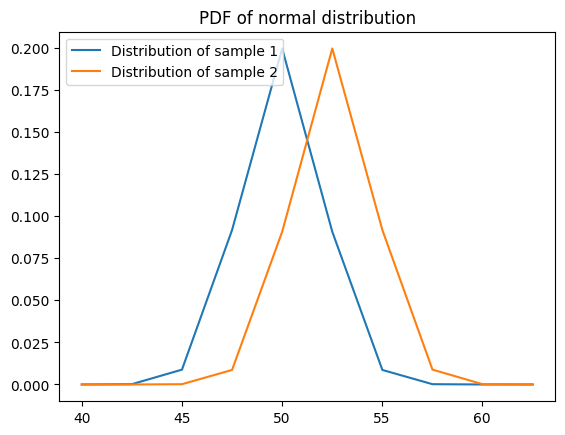

In [50]:
random.seed(888), np.random.seed(888) #very important: set random seed.
s1_mean,s1_stddev = 50, 2 # sample has mean of 200, std dev of 2
s1_samples = norm.rvs(size=60,loc=s1_mean, scale=s1_stddev)
s2_mean, s2_stddev = 52.52, 2 # population has mean of 210, std dev of 2
s2_samples = norm.rvs(size=60,loc=s2_mean, scale=s2_stddev)
x = np.linspace(s1_mean-10, s2_mean+10, 10)
plt.plot(x, norm.pdf(x,s1_mean,s1_stddev), label='Distribution of sample 1')
plt.plot(x, norm.pdf(x, s2_mean, s2_stddev), label='Distribution of sample 2')
plt.title('PDF of normal distribution')
plt.legend(loc="upper left")
plt.show()

#### Calculer le test t apparié pour la différence de moyenne

Notez que : Cette formule ressemble beaucoup à la différence de moyenne du test t sur 1 échantillon ($\sigma$ inconnue) que nous avons utilisée précédemment, mais dans ce cas, nous utilisons les <b>differences</b> entre les 2 échantillons pour le calcul et les deux tailles d'échantillon doivent être les mêmes. Je sais que cela ressemble à de la triche : nous le recadrons indirectement en un test t à 1 échantillon.

$$t = \frac{\bar{x}_D-\mu}{ \frac{s_D}{ \sqrt{n_D} } }$$

où df = n-1, $\bar{x}_D$ est la moyenne des différences et $\mu$ est 0 car nous avons émis l'hypothèse qu'il y avait 0 différence.

In [51]:
from scipy.stats import t
diff = s1_samples - s2_samples
t_score = (np.mean(diff) - 0) / (np.std(diff, ddof=1)/np.sqrt(len(diff)))
df = len(s1_samples)-1
t_score, (1-t.cdf(abs(t_score),df))*2, df

(-7.167830542580345, 1.4061010134014396e-09, 59)

Nous pourrions utiliser la fonction ttest_rel</a> de <a href='https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html'>scipy pour effectuer le test t apparié à 2 échantillons.

In [52]:
from scipy.stats import ttest_rel
# note that it returns the p-value for 2-sided test!
test_stat, p_value = ttest_rel(s1_samples,s2_samples)
test_stat, p_value

(-7.167830542580345, 1.406101031262486e-09)

## Test d'hypothèse sur 2 échantillons pour la différence de proportions

In [53]:
from scipy.stats import binom

Exemple de cas d'utilisation : nous souhaitons savoir si 2 pièces sont créées égales et s'il existe une différence entre elles.

Nous créons 2 distributions <b>binomiales</b> pour représenter les lancers de pièces de 2 pièces différentes. Pour la simulation, nous effectuons 100 tirages au sort (une série d'essais de Bernoulli), avec une probabilité de 0,55 et 0,5 d'obtenir face à chaque essai, pour chaque échantillon respectivement.

Remarque : chaque essai de Bernoulli n'a que deux résultats possibles (succès ou échec) et le paramètre p décrit la probabilité de succès.

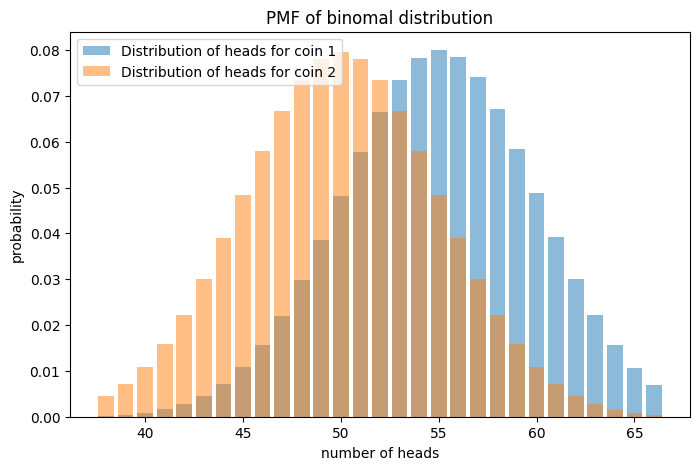

In [54]:
plt.figure(figsize=(8,5))
s2_samples_n, s2_samples_p = 100, 0.5
s1_samples_n, s1_samples_p = 100, 0.55
x = np.arange(binom.ppf(0.01, s1_samples_n, s1_samples_p)-5,binom.ppf(0.99, s2_samples_n, s2_samples_p)+5)
plt.bar(x, binom.pmf(x, n=s1_samples_n, p=s1_samples_p), alpha=0.5, label='Distribution of heads for coin 1')
plt.bar(x, binom.pmf(x, n=s2_samples_n, p=s2_samples_p), alpha=0.5, label='Distribution of heads for coin 2')
plt.title('PMF of binomal distribution')
plt.legend(loc="upper left"), plt.xlabel('number of heads'), plt.ylabel('probability')
plt.show()

D'après le PMF, nous avons pu voir que la distribution de la 2ème pièce culmine à 55, ce qui signifie que sur 100 lancers de pièces, la 2ème pièce obtient 55 faces la plupart du temps. En revanche, la 1ère pièce obtient 50 faces la plupart du temps. Nous pourrions également voir une certaine probabilité d'obtenir d'autres nombres en fonction de la variance.

### Tests d'hypothèses à 2 queues

Hypothèse nulle ($H_{0}$) : Il existe une différence <b>NO</b> entre les 2 pièces.

Hypothèse alternative ($H_{1}$) : Il y a une différence entre les 2 pièces.

#### Calculer le test z à 2 échantillons pour la différence de proportions

\begin{aligner}
Z
&= \frac{ p_1 - p_2}{\sqrt{\hat{p} (1 - \hat{p}) \left( \frac{1}{n_1} + \frac{1}{n_2} \right)}}
\fin{aligner}
où la variance groupée est :
$$\hat{p} = \frac{x_1+x_2}{n_1+n_2} $$

In [55]:
# manual method
pool_prop = (int(s1_samples_n* s1_samples_p) + int(s2_samples_n* s2_samples_p))/(s1_samples_n+s2_samples_n)
z_score = (s1_samples_p-s2_samples_p)/np.sqrt( pool_prop*(1-pool_prop)*((1/s1_samples_n)+(1/s2_samples_n) ) )
pool_prop, z_score, (1-norm.cdf(abs(z_score)))*2

(0.525, 0.7079923254047893, 0.47895002342035786)

Encore une fois, nous pourrions utiliser la fonction z-test du modèle de statistiques <a href='https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html'> </a> pour exécuter le test en 1 ligne :

In [56]:
#NOTE these parameters:
#count: number of successes, nobs: number of trials, alternative: The alt hypo
from statsmodels.stats.proportion import proportions_ztest
count = np.array([ int(s1_samples_n* s1_samples_p), int(s2_samples_n* s2_samples_p)])
nobs = np.array([s1_samples_n, s2_samples_n])
z_score, p_val = proportions_ztest(count, nobs=nobs, alternative='two-sided')
z_score, p_val

(0.7079923254047893, 0.478950023420358)

### Choisir 2 tests de queue ou 1 test de queue

En pratique, vous ne devez utiliser un test unilatéral que lorsque vous avez de bonnes raisons de penser que la différence ira dans une direction particulière. Un test bilatéral est plus conservateur qu'un test unilatéral car un test bilatéral utilise une statistique de test plus extrême pour rejeter l'hypothèse nulle.

## >2 échantillons Test d'hypothèse pour différents moyens (à suivre)

### Test ANOVA
Lorsque nous voulons comparer les moyennes entre plus de 2 échantillons, nous devons utiliser le test ANOVA. Il compare deux types de variation, la variation entre les moyennes de l'échantillon, ainsi que la variation au sein de chacun des échantillons. Cela nous indique s'il y a une différence entre les groupes mais pas exactement lequel.

La formule ANOVA unidirectionnelle, qui nous donne la statistique F :

$$ F=\frac{\text{Explained variance(between groups)}}{\text{Unexplained variance(within groups)}}  = \frac{\text{Sum of squares between groups}}{\text{Sum of squares for error}} = \frac{MST}{MSE} $$

Comme pour le test z, nous utiliserions la recherche de la valeur critique sur la distribution F pour déterminer si elle est significative.